# Training Deep Convolutional Neural Network
- Jiraphan Sakpisuttipong, 66070501009
- Pemika Chongkwanyuen, 66070501034
- Siraprapa Chinwongtan, 66070501055

Name your file to (first 2 student ID digit)_(last 4 student ID digit)*4.ipynb

## Lab Instruction

In this lab, you will learn to train a deep convolutional neural network using Keras library with Tensorflow backend. We will use  Cat vs Dog dataset.

See https://www.kaggle.com/c/dogs-vs-cats/data


### Your Turn! Dog or Cat Application

Now, it time to put everything together and develop and Cat vs Dog classifier model. Assume that you and your company want to get more attraction on your product by launching a new product that can classify whether it is a dog or a cat. You have decide that you want a precision more than 90 - 95% in order to launch to product.

You have a cat and dog dataset contain total of 25000 images, 12500 for cat and other half for a dog.

After successfully develop this model, you can try to play with it to see how it perform. (You can upload your selfies image to see you are a dog or a cat)

Some note before start a project:
1. You have to load a data into a project using any method
**suggest**
   

```
 !wget -c https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
 !unzip -qq Cat_Dog_data.zip
```


2. You have to plan on how you will split a data. (or no need for suggest method)
3. You have to preprocess your data before feed into a network. For example, cropping, padding, etc.
4. You can come up with any model or use pre-train model. It depend on you!

You have two week for this project so that you can compete with your competitor app! Now, create a new Jupyter notebook and start building a model!

In [ ]:
# =====================================
# STEP 1: Setup & Data Download
# =====================================
!wget -c https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
!unzip -qq Cat_Dog_data.zip

# Directory check
!ls Cat_Dog_data


--2025-10-08 19:14:29--  https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 54.231.169.16, 52.216.114.53, 52.217.233.152, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|54.231.169.16|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

replace Cat_Dog_data/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
test  train


In [ ]:
# =====================================
# STEP 2: Import libraries
# =====================================
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# =====================================
# STEP 3: Data Augmentation & Generator
# =====================================
train_dir = "Cat_Dog_data/train"

# Create image generators with augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    fill_mode='nearest',
    validation_split=0.2  # 80% train, 20% validation
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 18000 images belonging to 2 classes.
Found 4500 images belonging to 2 classes.


In [ ]:
# =====================================
# STEP 4: Build Model (Transfer Learning)
# =====================================
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(160,160,3))
base.trainable = False  # freeze pretrained base

# Add custom top layers
x = GlobalAveragePooling2D()(base.output)
x = Dense(256, activation='relu', kernel_regularizer='l2')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# =====================================
# STEP 5: Callbacks (Regularization helpers)
# =====================================
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
563/563 - 670s - 1s/step - accuracy: 0.9279 - loss: 2.8843 - val_accuracy: 0.9567 - val_loss: 1.7158 - learning_rate: 1.0000e-04
Epoch 2/10
563/563 - 665s - 1s/step - accuracy: 0.9522 - loss: 1.2144 - val_accuracy: 0.9607 - val_loss: 0.8331 - learning_rate: 1.0000e-04
Epoch 3/10
563/563 - 651s - 1s/step - accuracy: 0.9571 - loss: 0.6473 - val_accuracy: 0.9651 - val_loss: 0.4827 - learning_rate: 1.0000e-04
Epoch 4/10
563/563 - 649s - 1s/step - accuracy: 0.9582 - loss: 0.4034 - val_accuracy: 0.9604 - val_loss: 0.3264 - learning_rate: 1.0000e-04
Epoch 5/10
563/563 - 648s - 1s/step - accuracy: 0.9594 - loss: 0.2804 - val_accuracy: 0.9662 - val_loss: 0.2337 - learning_rate: 1.0000e-04
Epoch 6/10
563/563 - 663s - 1s/step - accuracy: 0.9607 - loss: 0.2154 - val_accuracy: 0.9627 - val_loss: 0.1968 - learning_rate: 1.0000e-04
Epoch 7/10
563/563 - 672s - 1s/step - accuracy: 0.9604 - loss: 0.1808 - val_accuracy: 0.9658 - val_loss: 0.1610 - learning_rate: 1.0000e-04
Epoch 8/10
563/563 -

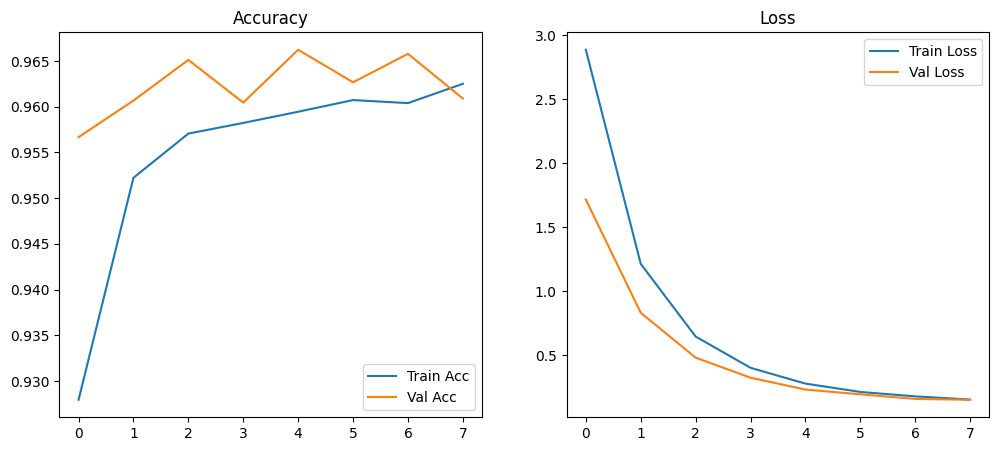

In [ ]:
# =====================================
# STEP 6: Training Phase 1 (Feature Extraction)
# =====================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

# Plot accuracy/loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()

Epoch 1/10
563/563 - 857s - 2s/step - accuracy: 0.9395 - loss: 0.2956 - val_accuracy: 0.9558 - val_loss: 0.2465 - learning_rate: 1.0000e-05
Epoch 2/10
563/563 - 851s - 2s/step - accuracy: 0.9546 - loss: 0.2481 - val_accuracy: 0.9658 - val_loss: 0.2140 - learning_rate: 1.0000e-05
Epoch 3/10
563/563 - 850s - 2s/step - accuracy: 0.9600 - loss: 0.2229 - val_accuracy: 0.9696 - val_loss: 0.2008 - learning_rate: 1.0000e-05
Epoch 4/10
563/563 - 843s - 1s/step - accuracy: 0.9619 - loss: 0.2162 - val_accuracy: 0.9722 - val_loss: 0.1896 - learning_rate: 1.0000e-05
Epoch 5/10
563/563 - 842s - 1s/step - accuracy: 0.9659 - loss: 0.1984 - val_accuracy: 0.9700 - val_loss: 0.1861 - learning_rate: 1.0000e-05
Epoch 6/10
563/563 - 848s - 2s/step - accuracy: 0.9680 - loss: 0.1854 - val_accuracy: 0.9698 - val_loss: 0.1791 - learning_rate: 1.0000e-05
Epoch 7/10
563/563 - 848s - 2s/step - accuracy: 0.9709 - loss: 0.1715 - val_accuracy: 0.9736 - val_loss: 0.1640 - learning_rate: 1.0000e-05
Epoch 8/10
563/563 -

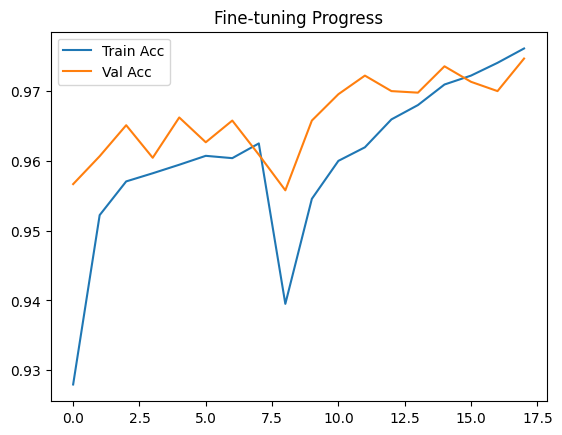

In [ ]:
# =====================================
# STEP 7: Fine-tuning the Base (Phase 2)
# =====================================
# Unfreeze last 40 layers of base for fine-tuning
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

# Merge both histories for visualization
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
plt.plot(acc, label='Train Acc'); plt.plot(val_acc, label='Val Acc')
plt.legend(); plt.title("Fine-tuning Progress")
plt.show()

In [ ]:
# Verify that predictions and filenames align
filenames = val_gen.filenames[:10]
for i, fname in enumerate(filenames[:5]):
    print(f"{fname} → Pred: {y_pred[i]}, True: {y_true[i]}")


cat/cat.0.jpg → Pred: [1], True: 0
cat/cat.1.jpg → Pred: [0], True: 0
cat/cat.10.jpg → Pred: [0], True: 0
cat/cat.100.jpg → Pred: [0], True: 0
cat/cat.1000.jpg → Pred: [1], True: 0


In [ ]:
# =====================================
# STEP 8: Evaluate Final Model
# =====================================
# Predict on validation generator
# Recreate only the validation generator
val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

y_pred = (model.predict(val_gen) > 0.5).astype(int)
y_true = val_gen.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))


Found 4500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


141/141 ━━━━━━━━━━━━━━━━━━━━ 131s 931ms/step
[[2196   54]
 [  76 2174]]
              precision    recall  f1-score   support

         Cat       0.97      0.98      0.97      2250
         Dog       0.98      0.97      0.97      2250

    accuracy                           0.97      4500
   macro avg       0.97      0.97      0.97      4500
weighted avg       0.97      0.97      0.97      4500



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


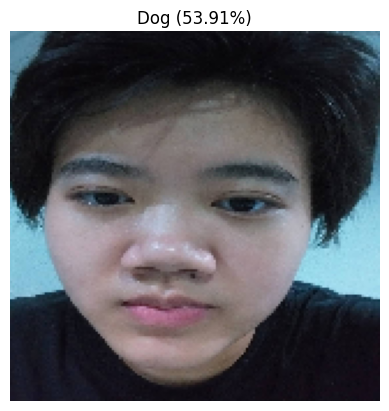

In [ ]:
# =====================================
# STEP 9: Test with Your Own Image
# =====================================
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(image_path):
    img = load_img(image_path, target_size=(160,160))
    img_arr = img_to_array(img)/255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    pred = model.predict(img_arr)[0][0]
    label = "Dog" if pred > 0.5 else "Cat"
    confidence = pred if pred > 0.5 else 1 - pred
    plt.imshow(img)
    plt.title(f"{label} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

# Example test (change path to any image)
predict_image("/content/154949.jpg")